In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np

# 1. LOAD DATA WITH CORRECT HEADER
# We use header=1 to select the second row as the column names
df = pd.read_excel('/content/drive/MyDrive/IE6318/Project_Files/Classification_Dataset.xlsx', header=1)

# 2. IDENTIFY COLUMN TYPES
# Columns that should be numeric but might contain 'U'
numeric_cols_to_clean = [
    'No of drilled shaft per bent',
    'Pier size/dia (in)',
    'Embedded Pier size/dia (in)',
    'Pier Spacing (ft)',
    'Pier unbraced length (ft)',
    'Bent Cap depth (ft)',
    'Bent Cap width (ft)',
    'Girder spacing (ft)'
]

# 3. CLEANING LOOP
for col in numeric_cols_to_clean:
    # Replace 'U' with NaN (Missing Value)
    df[col] = df[col].replace('U', np.nan)

    # Force convert to numbers (errors='coerce' turns any other non-numbers to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. ENCODE TARGET VARIABLE
# Map Deep to 1 and Shallow to 0
df['Target'] = df['Foundation Type'].map({'Deep': 1, 'Shallow': 0})

# 5. CREATE 'AGE' FEATURE
current_year = 2025
df['Bridge_Age'] = current_year - df['Years Build']

# Check the cleaned data structure
print("Cleaned Data Info:")
print(df.info())

# Show first 5 rows of the target and key numeric features
print(df[['Asset Name', 'Target', 'Bridge_Age', 'Pier size/dia (in)']].head())

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   SI                                      55 non-null     int64  
 1   Asset Name                              55 non-null     object 
 2   NBI 007: Facility Carried by Structure  55 non-null     object 
 3   NBI 006: Feature Intersected            55 non-null     object 
 4   Avg Daily Trafic                        55 non-null     int64  
 5   Regulatory Speed (mph)                  55 non-null     int64  
 6   Scour rating 113                        55 non-null     int64  
 7   Years Build                             55 non-null     int64  
 8   No of Lanes                             55 non-null     int64  
 9   Total Length (ft)                       55 non-null     float64
 10  Total Number of Spans                   55 no

/tmp/ipython-input-2037688748.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('U', np.nan)


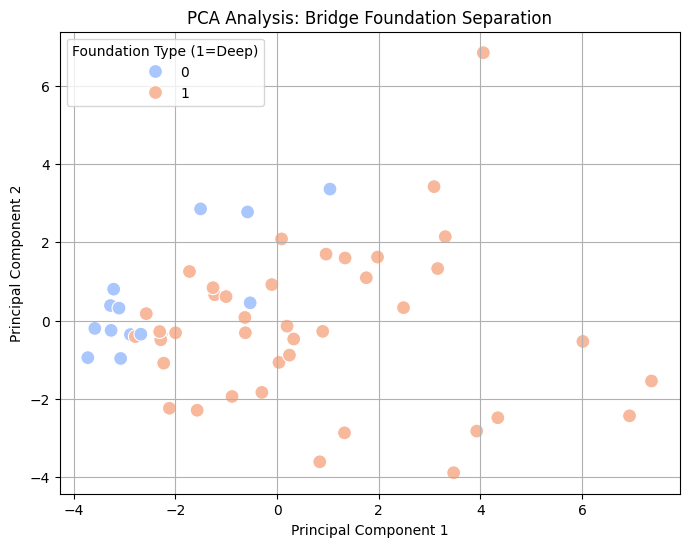

Original Feature Count: 93
Reduced Feature Count (PCA): 2
Explained Variance Ratio: [0.3113987  0.14953462]


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# 1. LOAD DATA (Skipping the first row of categories to get straight to headers)
df = pd.read_excel('/content/drive/MyDrive/IE6318/Project_Files/Classification_Dataset.xlsx', header=1)

# 2. DEFINE FEATURES
# Based on your file structure analysis
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]

categorical_features = [
    'NBI 006: Feature Intersected', 'Design Load', 'Girder Type',
    'Rail Type', 'Pier Shape'
]

target_col = 'Foundation Type'

# 3. CLEANING FUNCTION (Lecture 2 Concept)
# Convert columns meant to be numeric but containing 'U' or text
for col in numeric_features:
    # Force convert to numeric, turning 'U' and errors into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. FEATURE ENGINEERING
# Create Bridge Age (more useful than Year Built)
df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age') # Add to our list of numbers

# Map Target to Binary (1 = Deep, 0 = Shallow)
y = df[target_col].map({'Deep': 1, 'Shallow': 0})

# Ensure categorical features are string type before preprocessing
for col in categorical_features:
    df[col] = df[col].astype(str)

X = df[numeric_features + categorical_features]

# 5. PREPROCESSING PIPELINE (Lecture 2 & 10)
# Numeric: Impute missing with Median -> Scale (Z-Score)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing data
    ('scaler', StandardScaler()) # Essential for PCA!
])

# Categorical: Impute missing -> OneHotEncode (explicitly set sparse_output=False)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. RUN PCA (Lecture 10)
# We fit the preprocessor first to get clean data
X_clean = preprocessor.fit_transform(X)

# Initialize PCA to keep 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

# 7. VISUALIZATION
# Plot the first 2 Principal Components to see if Deep vs Shallow separates well
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', s=100)
plt.title('PCA Analysis: Bridge Foundation Separation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Foundation Type (1=Deep)')
plt.grid(True)
plt.show()

print(f"Original Feature Count: {X_clean.shape[1]}")
print(f"Reduced Feature Count (PCA): {X_pca.shape[1]}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

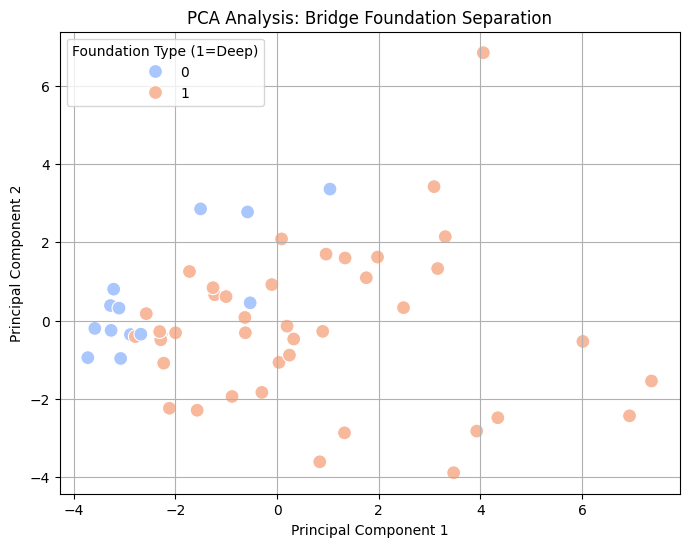

Original Feature Count: 93
Reduced Feature Count (PCA): 2
Explained Variance Ratio: [0.3113987  0.14953462]


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# 1. LOAD DATA (Skipping the first row of categories to get straight to headers)
df = pd.read_excel('/content/drive/MyDrive/IE6318/Project_Files/Classification_Dataset.xlsx', header=1)

# 2. DEFINE FEATURES
# Based on your file structure analysis
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]

categorical_features = [
    'NBI 006: Feature Intersected', 'Design Load', 'Girder Type',
    'Rail Type', 'Pier Shape'
]

target_col = 'Foundation Type'

# 3. CLEANING FUNCTION (Lecture 2 Concept)
# Convert columns meant to be numeric but containing 'U' or text
for col in numeric_features:
    # Force convert to numeric, turning 'U' and errors into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. FEATURE ENGINEERING
# Create Bridge Age (more useful than Year Built)
df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age') # Add to our list of numbers

# Map Target to Binary (1 = Deep, 0 = Shallow)
y = df[target_col].map({'Deep': 1, 'Shallow': 0})

# Ensure categorical features are string type before preprocessing
for col in categorical_features:
    df[col] = df[col].astype(str)

X = df[numeric_features + categorical_features]

# 5. PREPROCESSING PIPELINE (Lecture 2 & 10)
# Numeric: Impute missing with Median -> Scale (Z-Score)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing data
    ('scaler', StandardScaler()) # Essential for PCA!
])

# Categorical: Impute missing -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. RUN PCA (Lecture 10)
# We fit the preprocessor first to get clean data
X_clean = preprocessor.fit_transform(X)

# Initialize PCA to keep 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

# 7. VISUALIZATION
# Plot the first 2 Principal Components to see if Deep vs Shallow separates well
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', s=100)
plt.title('PCA Analysis: Bridge Foundation Separation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Foundation Type (1=Deep)')
plt.grid(True)
plt.show()

print(f"Original Feature Count: {X_clean.shape[1]}")
print(f"Reduced Feature Count (PCA): {X_pca.shape[1]}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

To keep 95% variance, PCA increased components from 2 to: 19

--- Model Performance ---
Accuracy: 0.73

Classification Report:
               precision    recall  f1-score   support

     Shallow       0.00      0.00      0.00         3
        Deep       0.73      1.00      0.84         8

    accuracy                           0.73        11
   macro avg       0.36      0.50      0.42        11
weighted avg       0.53      0.73      0.61        11



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


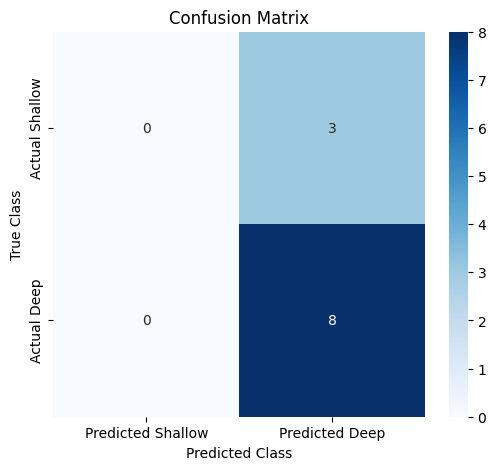

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Assuming df, X, and y are already defined from previous cells
# (df, numeric_features, categorical_features, target_col, X, y should be available in the kernel state)

# 5. PREPROCESSING PIPELINE  - Re-define to include sparse_output=False
# Numeric: Impute missing with Median -> Scale (Z-Score)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing data
    ('scaler', StandardScaler()) # Essential for PCA!
])

# Categorical: Impute missing -> OneHotEncode (explicitly set sparse_output=False)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 1. ADJUST PCA FOR MODELING
# Instead of 2 components, we keep 95% of the information
# Note: We use the 'preprocessor' from the previous step
X_clean = preprocessor.fit_transform(X) # Transform data first

pca_modeling = PCA(n_components=0.95, svd_solver='full')   # Keep 95% variance, use 'full' solver
X_pca_final = pca_modeling.fit_transform(X_clean)

print(f"To keep 95% variance, PCA increased components from 2 to: {pca_modeling.n_components_}")

# 2. TRAIN/TEST SPLIT
# We hide 20% of the bridges (approx 11 bridges) to test the model later
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_final, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TRAIN THE RANDOM FOREST
# n_estimators=100 means we create 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. PREDICT & EVALUATE
y_pred = rf_model.predict(X_test)

# 5. RESULTS DISPLAY
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Shallow', 'Deep']))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Shallow', 'Predicted Deep'],
            yticklabels=['Actual Shallow', 'Actual Deep'])
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

--- Cross-Validation Results (5 Folds) ---
Average Accuracy: 0.85 (+/- 0.19)
Average F1 Score: 0.69

--- Improved Classification Report ---
              precision    recall  f1-score   support

     Shallow       1.00      0.38      0.56        13
        Deep       0.84      1.00      0.91        42

    accuracy                           0.85        55
   macro avg       0.92      0.69      0.73        55
weighted avg       0.88      0.85      0.83        55



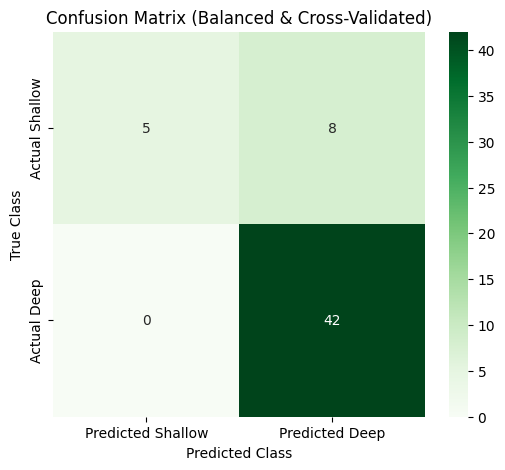

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer

# 1. SETUP THE IMPROVED MODEL
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # <--- CRITICAL FIX
    random_state=42
)

# 2. SETUP CROSS-VALIDATION (5-Fold)
# We use the entire X_pca_final dataset instead of just X_train/X_test
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. RUN EVALUATION
# We want to see F1-Score (balance of precision/recall) instead of just Accuracy
f1_scores = cross_val_score(rf_balanced, X_pca_final, y, cv=cv, scoring='f1_macro')
acc_scores = cross_val_score(rf_balanced, X_pca_final, y, cv=cv, scoring='accuracy')

print(f"--- Cross-Validation Results (5 Folds) ---")
print(f"Average Accuracy: {acc_scores.mean():.2f} (+/- {acc_scores.std() * 2:.2f})")
print(f"Average F1 Score: {f1_scores.mean():.2f}")

# 4. GENERATE A NEW REPORT (Aggregated over all folds)
y_pred_cv = cross_val_predict(rf_balanced, X_pca_final, y, cv=cv)

print("\n--- Improved Classification Report ---")
print(classification_report(y, y_pred_cv, target_names=['Shallow', 'Deep']))

# 5. VISUALIZE THE FIX
conf_matrix = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Shallow', 'Predicted Deep'],
            yticklabels=['Actual Shallow', 'Actual Deep'])
plt.title('Confusion Matrix (Balanced & Cross-Validated)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

--- Results without PCA ---
Average Accuracy: 0.96 (+/- 0.09)

Classification Report:
               precision    recall  f1-score   support

     Shallow       1.00      0.85      0.92        13
        Deep       0.95      1.00      0.98        42

    accuracy                           0.96        55
   macro avg       0.98      0.92      0.95        55
weighted avg       0.97      0.96      0.96        55



/tmp/ipython-input-3834985944.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


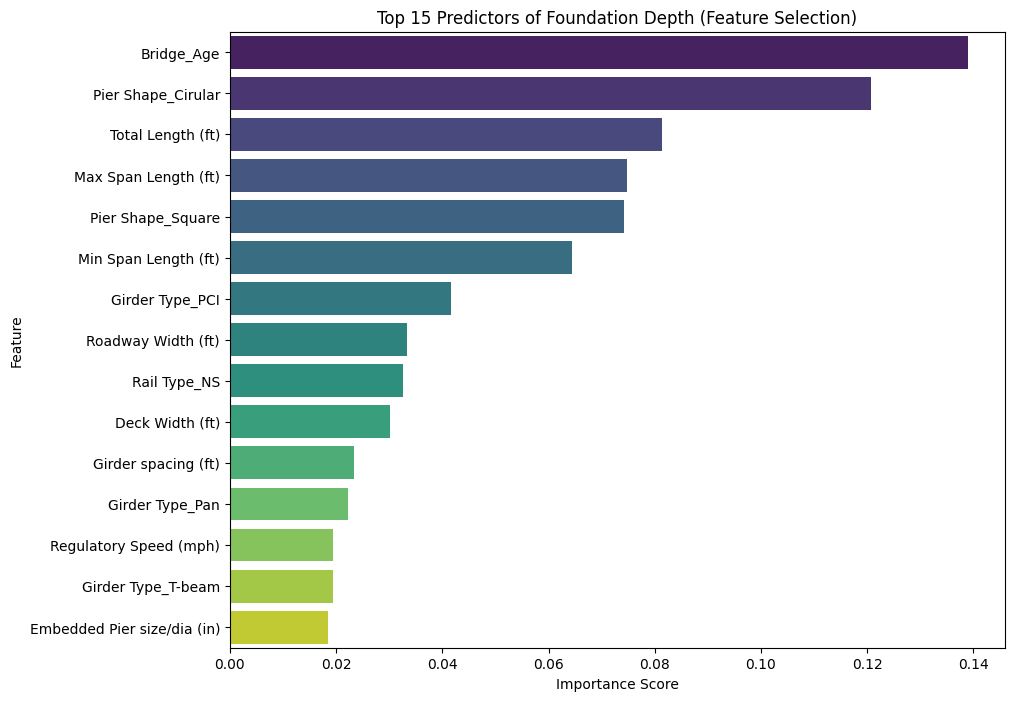

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# 1. USE RAW DATA (Skip PCA)
# We use the 'preprocessor' from the earlier step, but NO PCA.
X_raw = preprocessor.fit_transform(X)

# Get feature names back (for the report)
# Numeric names
feat_names = numeric_features.copy()
# Categorical names (from OneHotEncoder)
cat_encoder = preprocessor.named_transformers_['cat']['encoder']
cat_names = cat_encoder.get_feature_names_out(categorical_features)
feat_names.extend(cat_names)

# 2. TRAIN MODEL ON RAW DATA
# We keep class_weight='balanced' to help with the Recall problem
rf_raw = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 3. CROSS-VALIDATION EVALUATION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate scores
acc_scores = cross_val_score(rf_raw, X_raw, y, cv=cv, scoring='accuracy')
y_pred_cv = cross_val_predict(rf_raw, X_raw, y, cv=cv)

print(f"--- Results without PCA ---")
print(f"Average Accuracy: {acc_scores.mean():.2f} (+/- {acc_scores.std() * 2:.2f})")
print("\nClassification Report:\n", classification_report(y, y_pred_cv, target_names=['Shallow', 'Deep']))

# 4. FEATURE IMPORTANCE (Lecture 10)
# We fit the model on the whole dataset once to extract importance
rf_raw.fit(X_raw, y)
importances = rf_raw.feature_importances_

# Create a DataFrame for plotting
feature_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(15) # Top 15

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 15 Predictors of Foundation Depth (Feature Selection)')
plt.xlabel('Importance Score')
plt.show()

Running Cross-Validation on 4 Models...

--- Model Comparison Table ---
                 Model  Accuracy  Safety (Recall)  F1 Score
0        Random Forest  0.963636         0.916667  0.935521
2    Gradient Boosting  0.945455         0.925000  0.922118
1  SVM (Radial Kernel)  0.890909         0.826389  0.835359
3          Naive Bayes  0.890909         0.890278  0.856596


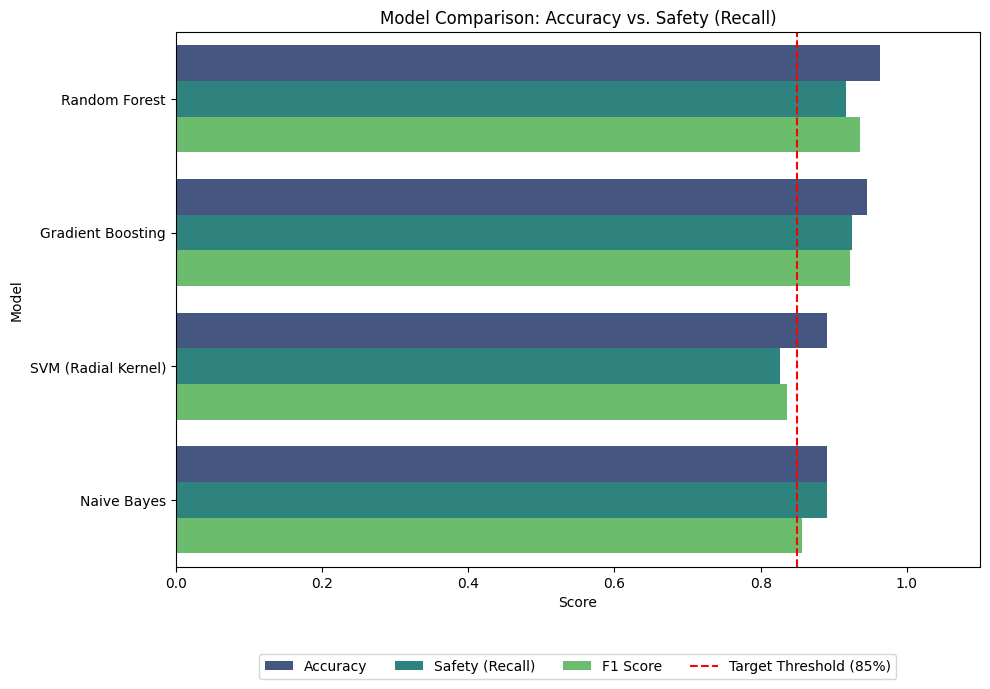

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 1. DEFINE MODELS
# We use a dictionary to loop through them easily
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM (Radial Kernel)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Naive Bayes": GaussianNB()
}

# 2. SETUP METRICS
# We want to measure three things:
# - accuracy: Overall correctness
# - recall_macro: How well it finds 'Shallow' foundations (Safety)
# - f1_macro: The balance between precision and recall
scoring = ['accuracy', 'recall_macro', 'f1_macro']

# 3. RUN THE TOURNAMENT
results_list = []
# We use StratifiedKFold to ensure every test set has both Deep and Shallow bridges
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running Cross-Validation on 4 Models...")

for name, model in models.items():
    # cv_results returns a dictionary of scores for each fold
    cv_results = cross_validate(model, X_raw, y, cv=cv, scoring=scoring)

    # Store the average of the 5 folds
    results_list.append({
        "Model": name,
        "Accuracy": cv_results['test_accuracy'].mean(),
        "Safety (Recall)": cv_results['test_recall_macro'].mean(), # Renamed for clarity in plot
        "F1 Score": cv_results['test_f1_macro'].mean()
    })

# 4. DISPLAY RESULTS TABLE
comparison_df = pd.DataFrame(results_list).sort_values(by='Accuracy', ascending=False)
print("\n--- Model Comparison Table ---")
print(comparison_df)

# 5. VISUALIZE COMPARISON (Fixed Legend)
# Melt dataframe for easier plotting with Seaborn
plot_df = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 7)) # Increased height slightly to fit legend below
sns.barplot(x="Score", y="Model", hue="Metric", data=plot_df, palette="viridis")

plt.title("Model Comparison: Accuracy vs. Safety (Recall)")
plt.xlim(0, 1.1) # Add a little space on the right
plt.axvline(0.85, color='red', linestyle='--', label='Target Threshold (85%)')

# --- FIX: Move Legend Below the Plot ---
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.tight_layout() # Adjusts spacing automatically
plt.show()

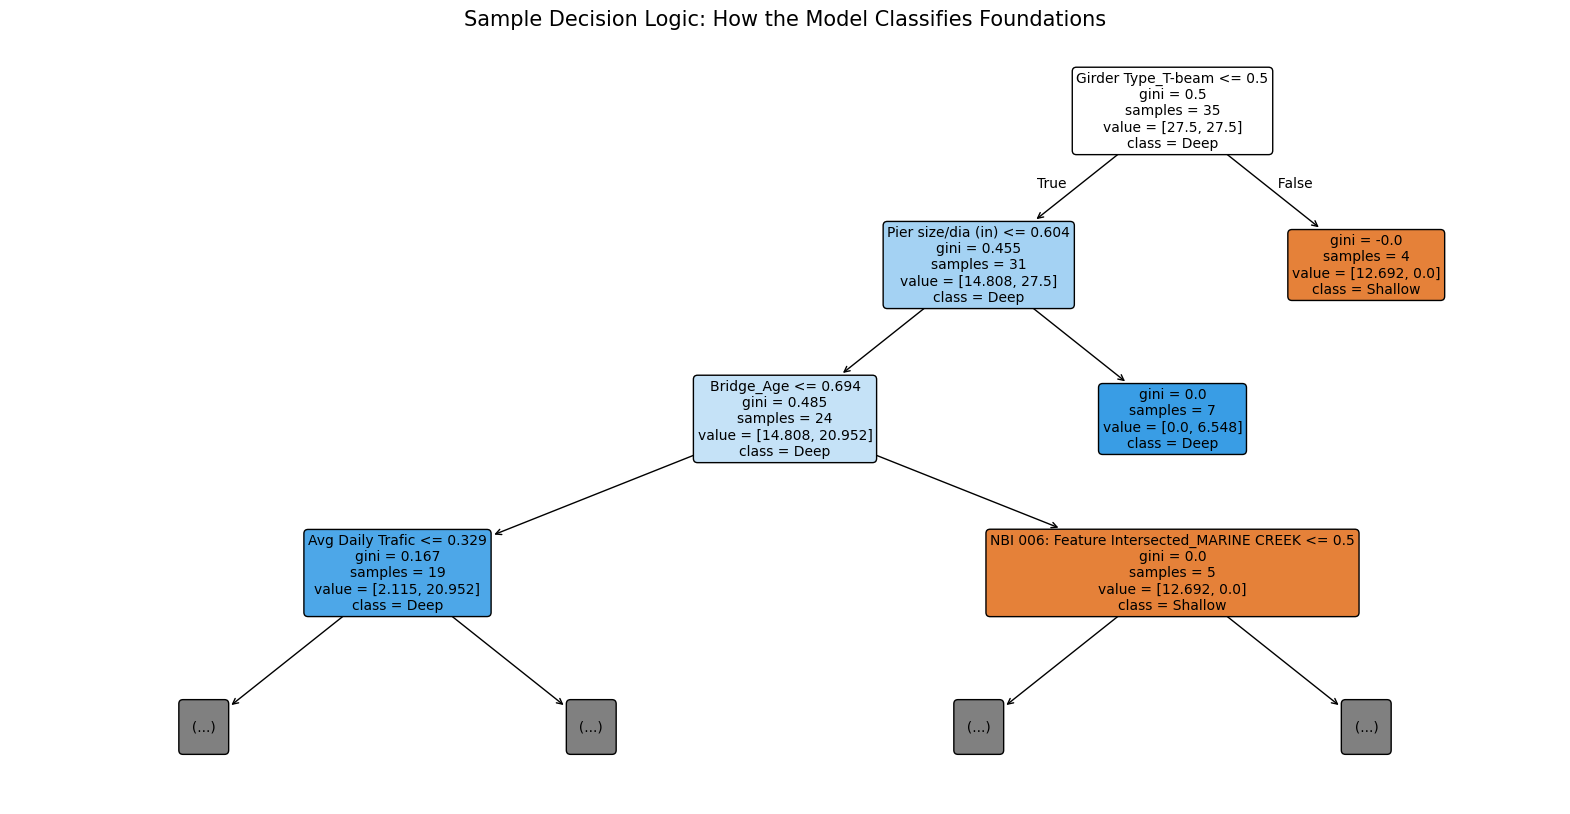

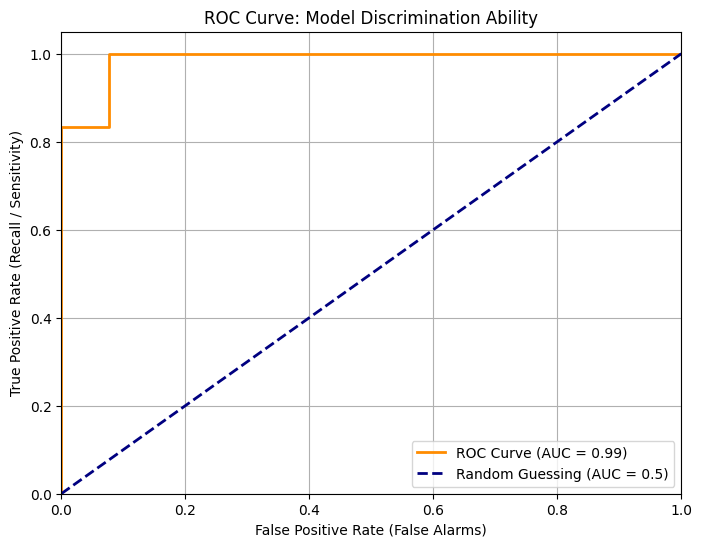

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import cross_val_predict

# --- PART 1: DECISION TREE VISUALIZATION ---
# Since Random Forest is a collection of 100 trees, we visualize ONE representative tree
# to understand the logic (e.g., "If Age > 40...").

# 1. Get the Feature Names back (so the plot shows "Age" instead of "Feature 1")
# (Re-extracting names from your preprocessor to be safe)
numeric_names = numeric_features
cat_encoder = preprocessor.named_transformers_['cat']['encoder']
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_names + cat_names

# 2. Plot the Tree
plt.figure(figsize=(20, 10))
plot_tree(rf_raw.estimators_[0], # Take the first tree from the forest
          feature_names=all_feature_names,
          class_names=['Shallow', 'Deep'],
          filled=True,
          rounded=True,
          max_depth=3, # Limit depth so text is readable
          fontsize=10)
plt.title("Sample Decision Logic: How the Model Classifies Foundations", fontsize=15)
plt.show()


# --- PART 2: ROC CURVE (Lecture 4) ---
# This shows the trade-off between Sensitivity (finding Shallow foundations)
# and Specificity (avoiding false alarms).

# 1. Get Probabilities using Cross-Validation (Fairer than using just one test set)
# We need the probability of being "Deep" (class 1)
y_probas = cross_val_predict(rf_raw, X_raw, y, cv=cv, method='predict_proba')
y_scores = y_probas[:, 1] # Score for 'Deep' class

# 2. Calculate ROC Metrics
fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

# 3. Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('ROC Curve: Model Discrimination Ability')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

'Bridge_Age' is at index 19
Found a representative tree! Tree #11 starts with Bridge_Age.


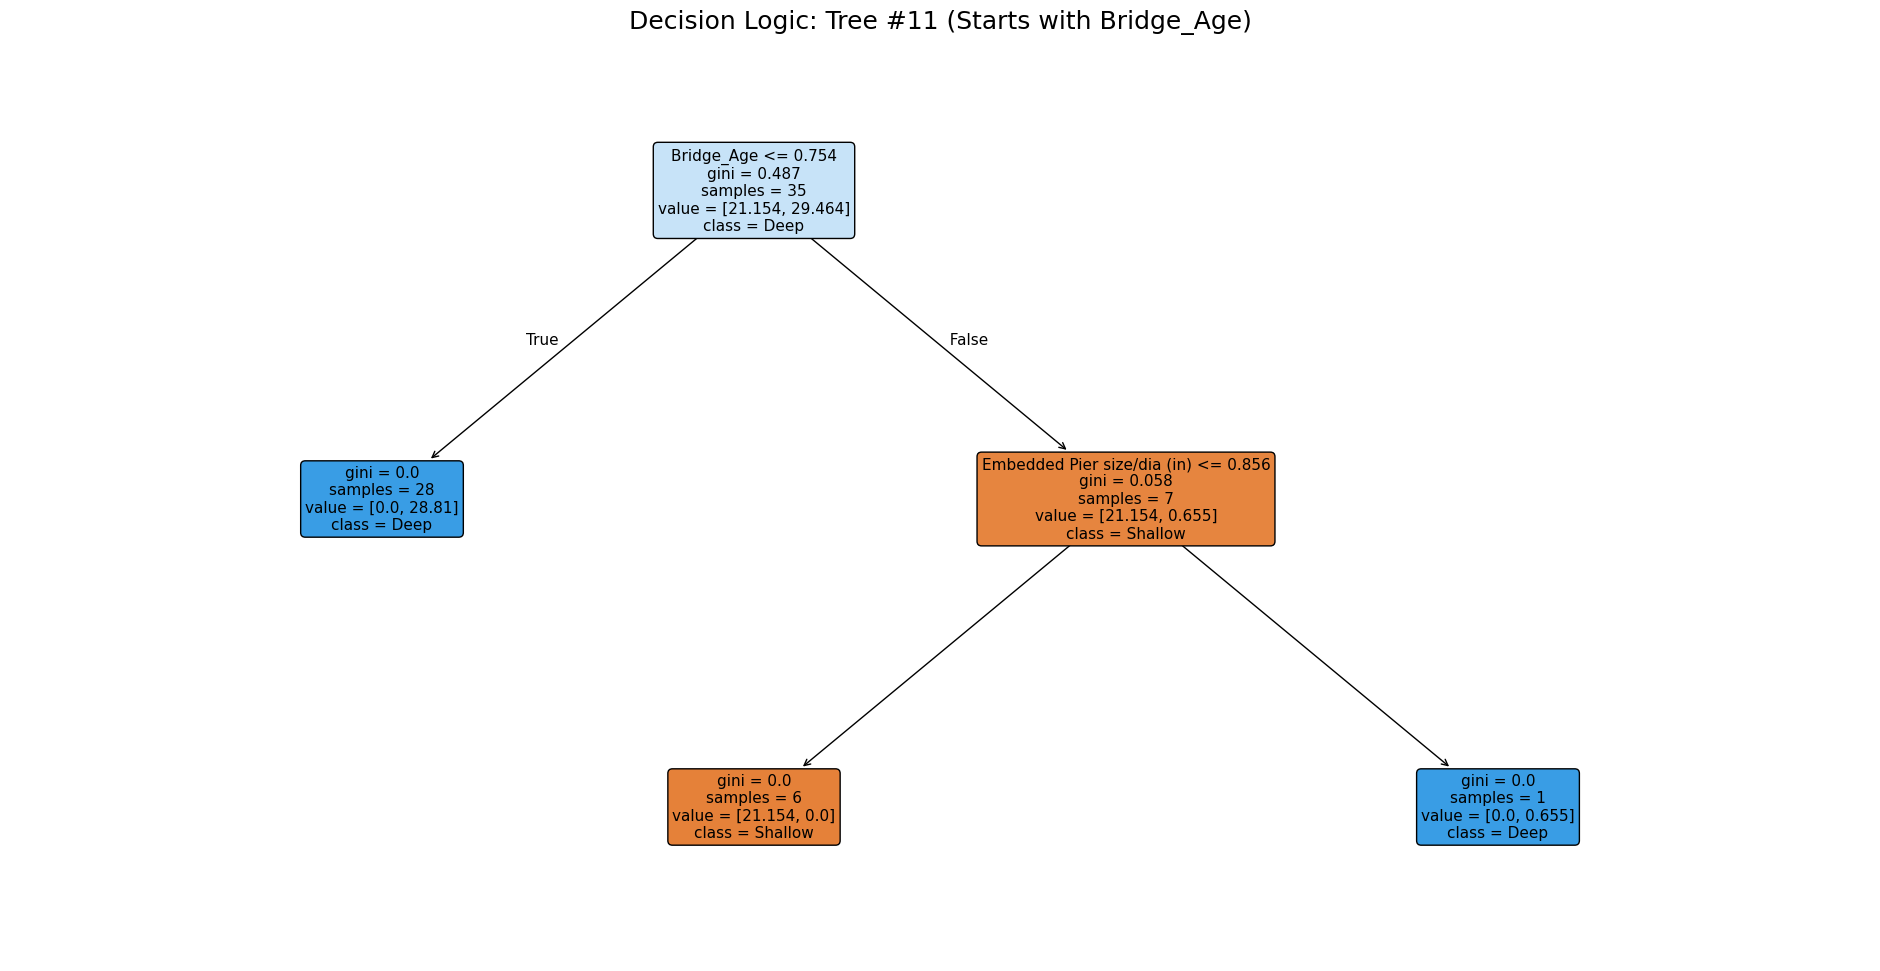

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. IDENTIFY THE INDEX OF "BRIDGE AGE"
# We need to know which number in the list corresponds to 'Bridge Age'
# (Adjust the string 'Bridge Age' if your column is named slightly differently, e.g., 'Age')
target_feature = 'Bridge_Age'

try:
    target_index = all_feature_names.index(target_feature)
    print(f"'{target_feature}' is at index {target_index}")
except ValueError:
    print(f"Error: Could not find '{target_feature}' in the list. Printing first 5 names to check:")
    print(all_feature_names[:5])
    # Stop here if name is wrong, otherwise continue

# 2. SEARCH FOR A TREE THAT SPLITS ON THIS FEATURE FIRST
selected_tree = None
tree_id = 0

for i, estimator in enumerate(rf_raw.estimators_):
    # The feature used for the root split is at index 0 of the underlying tree structure
    if estimator.tree_.feature[0] == target_index:
        selected_tree = estimator
        tree_id = i
        break

if selected_tree:
    print(f"Found a representative tree! Tree #{tree_id} starts with {target_feature}.")

    # 3. PLOT THIS SPECIFIC TREE
    plt.figure(figsize=(24, 12))
    plot_tree(selected_tree,
              feature_names=all_feature_names,
              class_names=['Shallow', 'Deep'],
              filled=True,
              rounded=True,
              max_depth=3,
              fontsize=11)
    plt.title(f"Decision Logic: Tree #{tree_id} (Starts with {target_feature})", fontsize=18)
    plt.show()
else:
    print(f"No tree in the forest started with {target_feature}. Try re-running the model or picking the 2nd best feature.")